# German Credit Data – Exploratory Data Analysis

## Objective
The goal of this analysis is to explore borrower characteristics and identify patterns associated with credit risk (good vs. bad).

## Business Context
This analysis is framed in a retail banking context, focusing on interpretable insights relevant for credit risk assessment.

In [1]:
#importing packages and functions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, chi2_contingency, pearsonr
from src.data_cleaning import prepare_data

sns.set_style("ticks")
sns.set_palette("colorblind")

In [2]:
#reading the dataset
original_data = pd.read_csv("../data/raw/SouthGermanCredit.asc", sep =" ")
#preparing data using the codetable
code_table = "../data/raw/codetable.txt"
df = prepare_data(original_data,code_table)
#checking first rows
df.head()

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,no checking account,18,all credits at this bank paid back duly,car (used),1049,unknown/no savings account,< 1 yr,< 20,female : non-single or male : single,none,...,car or other,21,none,for free,1,skilled employee/official,0 to 2,no,no,good
1,no checking account,9,all credits at this bank paid back duly,others,2799,unknown/no savings account,1 <= ... < 4 yrs,25 <= ... < 35,male : married/widowed,none,...,unknown / no property,36,none,for free,2-3,skilled employee/official,3 or more,no,no,good
2,... < 0 DM,12,no credits taken/all credits paid back duly,retraining,841,... < 100 DM,4 <= ... < 7 yrs,25 <= ... < 35,female : non-single or male : single,none,...,unknown / no property,23,none,for free,1,unskilled - resident,0 to 2,no,no,good
3,no checking account,12,all credits at this bank paid back duly,others,2122,unknown/no savings account,1 <= ... < 4 yrs,20 <= ... < 25,male : married/widowed,none,...,unknown / no property,39,none,for free,2-3,unskilled - resident,3 or more,no,yes,good
4,no checking account,12,all credits at this bank paid back duly,others,2171,unknown/no savings account,1 <= ... < 4 yrs,< 20,male : married/widowed,none,...,car or other,38,bank,rent,2-3,unskilled - resident,0 to 2,no,yes,good


## Data Overview

We start by inspecting the dataset structure, data types, and potential data quality issues.

In [3]:
#checking data structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   status                   1000 non-null   category
 1   duration                 1000 non-null   int64   
 2   credit_history           1000 non-null   category
 3   purpose                  1000 non-null   category
 4   amount                   1000 non-null   int64   
 5   savings                  1000 non-null   category
 6   employment_duration      1000 non-null   category
 7   installment_rate         1000 non-null   category
 8   personal_status_sex      1000 non-null   category
 9   other_debtors            1000 non-null   category
 10  present_residence        1000 non-null   category
 11  property                 1000 non-null   category
 12  age                      1000 non-null   int64   
 13  other_installment_plans  1000 non-null   category
 14  housing  

In [4]:
#check for duplicate rows
df.duplicated().any()

np.False_

In [5]:
#summary statistics numeric
df.describe(include="number")

,duration,amount,age
count,1000.000000,1000.00000,1000.00000
mean,20.903000,3271.24800,35.54200
std,12.058814,2822.75176,11.35267
min,4.000000,250.00000,19.00000
25%,12.000000,1365.50000,27.00000
50%,18.000000,2319.50000,33.00000
75%,24.000000,3972.25000,42.00000
max,72.000000,18424.00000,75.00000


In [6]:
#summary statistics categorical
df.describe(include="category")

,status,credit_history,purpose,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,present_residence,property,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
count,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,4,5,10,5,5,4,4,3,4,4,3,3,4,4,2,2,2,2
top,... >= 200 DM / salary for at least 1 year,no credits taken/all credits paid back duly,furniture/equipment,unknown/no savings account,1 <= ... < 4 yrs,< 20,male : married/widowed,none,>= 7 yrs,building soc. savings agr./life insurance,none,rent,1,skilled employee/official,0 to 2,no,no,good
freq,394,530,280,603,339,476,548,907,413,332,814,714,633,630,845,596,963,700


 **Summary**:
- the average **age** is 35.54 with standard deviation of 11.37 years
- the average **credit amount** is 3271.26 DM with standard deviation of 2822.74 DM
- the average **credit duration** is 20.90 years with standard deviation of 12.06 years

## Data Plausibility & Feature Relationships

Before analyzing credit risk, we examine relationships between key variables
to validate data consistency and better understand the structure of the portfolio.
We also include a short univariate Analysis of numerical variables.

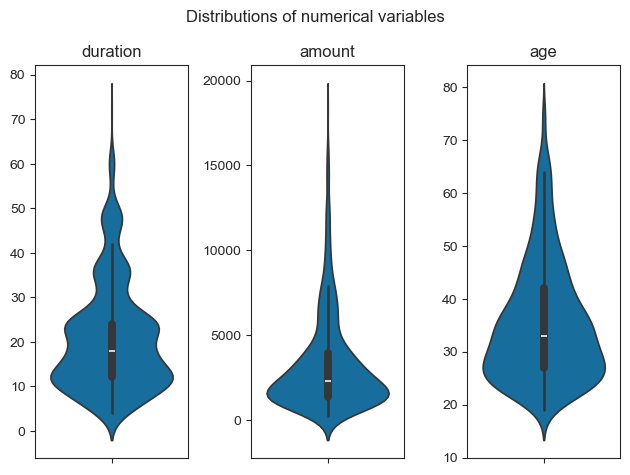

In [7]:
#plotting distributions for numeric variables
i=1
for col in df.select_dtypes("number").columns:
    plt.subplot(1,3,i)
    sns.violinplot(data = df, y = col)
    plt.title(col)
    plt.ylabel(None)
    i += 1

plt.suptitle("Distributions of numerical variables")
plt.tight_layout()

Text(0.5, 1.05, 'Pairplot of numerical variables')

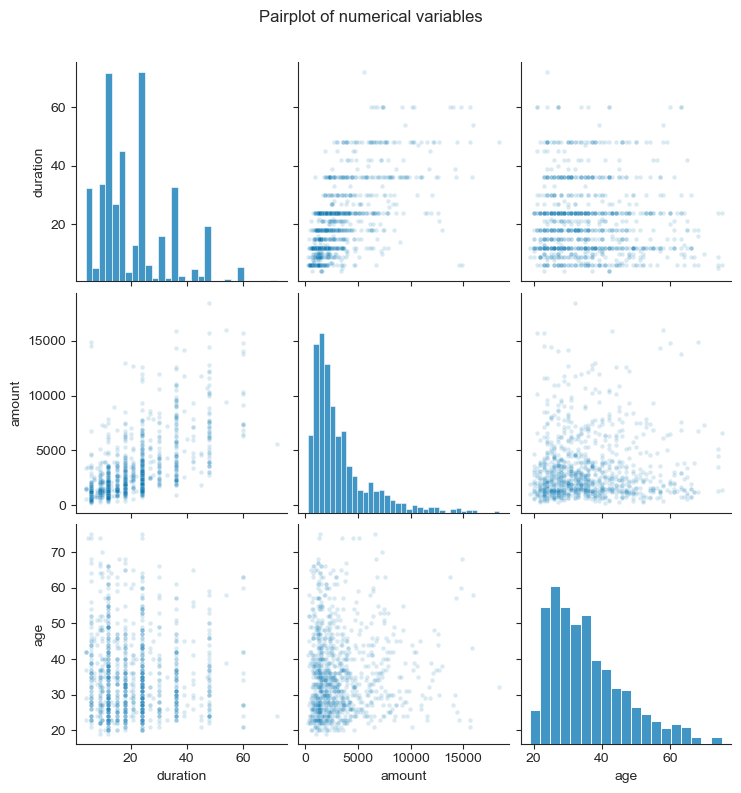

In [8]:
sns.pairplot(data=df.select_dtypes("number"),plot_kws={"s": 10, "alpha": 0.15})
plt.suptitle("Pairplot of numerical variables",y=1.05)

In [9]:
#skewness and kurtosis
num_cols = df.select_dtypes(include="number").columns

for col in num_cols:
    print(f"{col}: Skewness: {df[col].skew()}, Kurtosis: {df[col].kurt()}")

duration: Skewness: 1.0941841715555418, Kurtosis: 0.9197813600546372
amount: Skewness: 1.9495942869127831, Kurtosis: 4.292480607275049
age: Skewness: 1.0247120249859745, Kurtosis: 0.6205294816308626


Text(0.5, 1.0, 'Correlation Matrix of numerical variables')

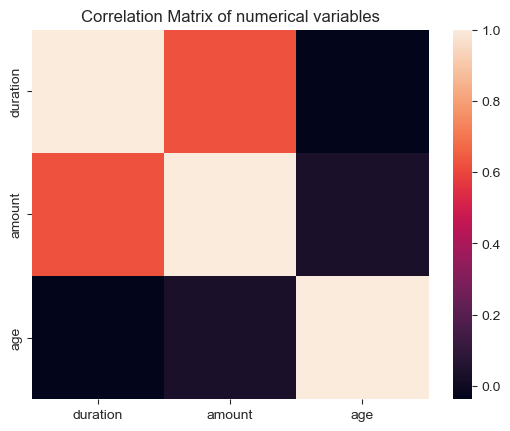

In [10]:
sns.heatmap(data=df.select_dtypes("number").corr())
plt.title("Correlation Matrix of numerical variables")

**Summary**:
- The distributions for numeric variables are somewhat right-skewed with longer tails.
- Larger loans tend to be associated with longer durations, reflecting standard loan structuring.
- Age does not seem to be a correlating factor with duration or amount.

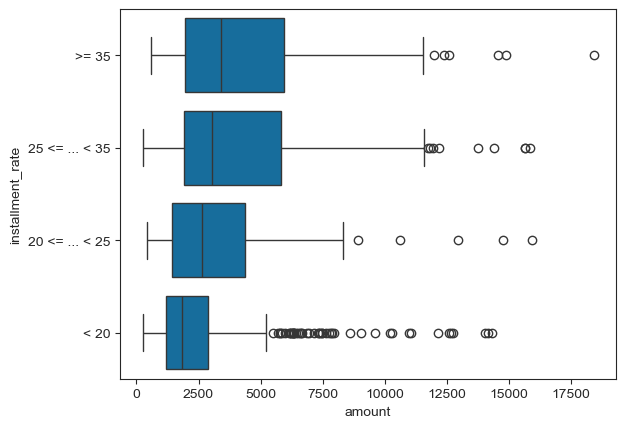

In [11]:
sns.boxplot(data=df, y="installment_rate", x="amount")
plt.show()

Business-related purposes tend to involve higher loan amounts, which aligns with economic expectations. However, note the bandwidth of loan amounts is quite large in this category.
Other credit types cover far smaller ranges, with consumer credits having a large quantity of outliers.

<Axes: xlabel='amount', ylabel='property'>

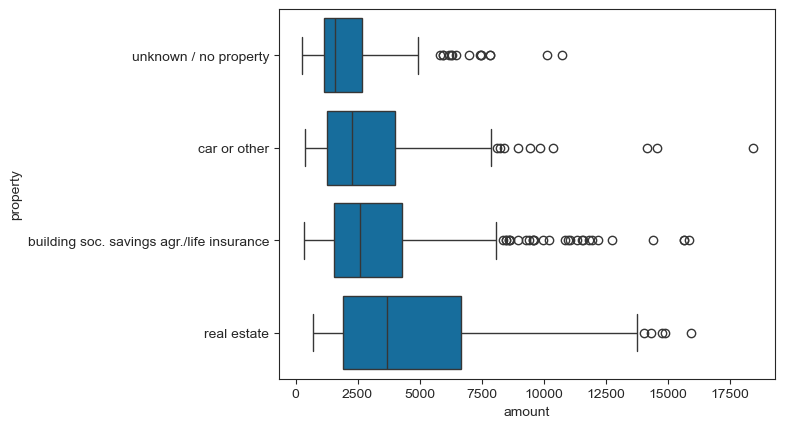

In [12]:
sns.boxplot(data=df, x="amount", y="property")

Higher valued property / collateral seems to be associated with higher credit amounts.KK

Purpose of credit has 11 distinct features. We group some features for robustness and readability.

<Axes: xlabel='amount', ylabel='purpose_grouped'>

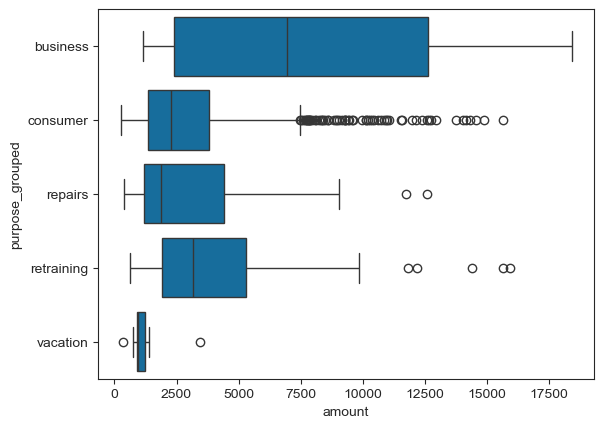

In [13]:
df["purpose_grouped"] = df["purpose"].astype("str").where(df["purpose"].isin(["repairs","education","vacation","retraining","business"]),"consumer").astype("category")
sns.boxplot(data=df, y="purpose_grouped", x="amount")

Higher credit amounts are associated with higher credit burden in relation to disposable income.


These relationships confirm that the dataset reflects realistic lending patterns.

We now move to analyzing how these factors relate to credit risk.

## Key Risk Drivers

We now analyze how key features relate to credit risk.
Focus is placed on:
- Credit Amount
- Duration
- Age
- Credit History
- Checking Account Status
- Savings
- Property
- Installment Rate
- Purpose
- Job
- Emplyoment Duration

### Target Variable Distribution

Understanding the balance between good and bad credit risk is essential.

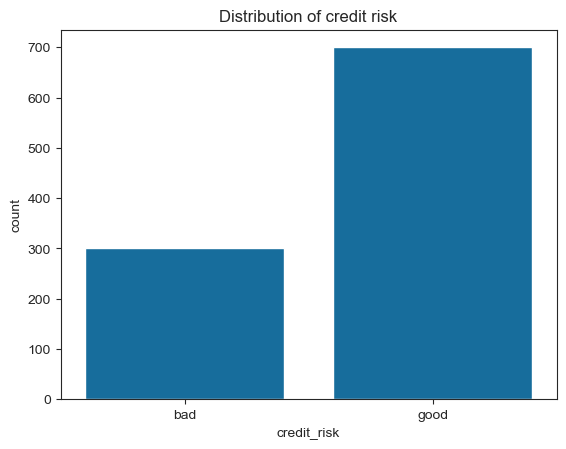

In [14]:
#risk distribution
sns.countplot(data=df, x="credit_risk")
plt.title("Distribution of credit risk")
plt.show()

The dataset shows a class imbalance with more good than bad credit cases.

### Credit Risk vs numerical features

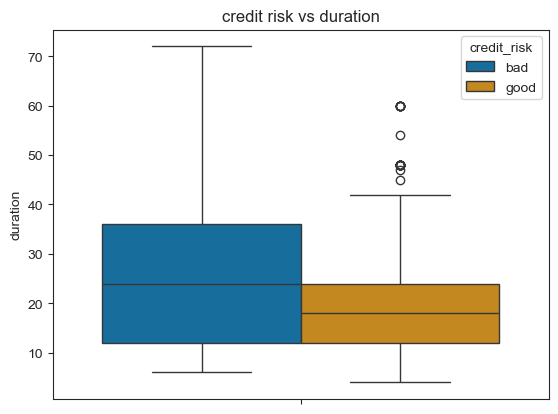

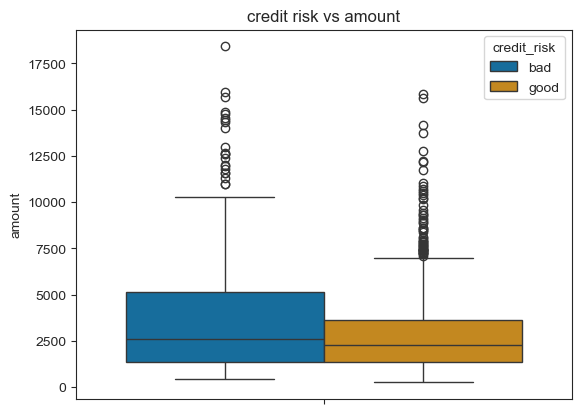

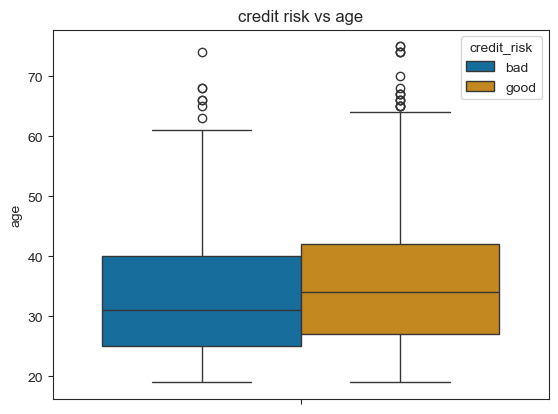

In [15]:
for col in df.select_dtypes("number").columns:
    sns.boxplot(data = df, y = col, hue="credit_risk")
    plt.title(f"credit risk vs {col}")
    plt.show()


Higher credit amounts and longer durations show a tendency toward increased risk, though overlap exists. Age does not seem to be a contributing factor.

### Credit risk vs categorical features

When analysing these features we have to take into account the prior distribution of 70% good vs. 30% bad credit risk.

credit_risk                                       bad      good
credit_history                                                 
delay in paying off in the past              0.625000  0.375000
critical account/other credits elsewhere     0.571429  0.428571
no credits taken/all credits paid back duly  0.318868  0.681132
existing credits paid back duly till now     0.318182  0.681818
all credits at this bank paid back duly      0.170648  0.829352


Text(0.5, 1.0, 'credit history vs risk')

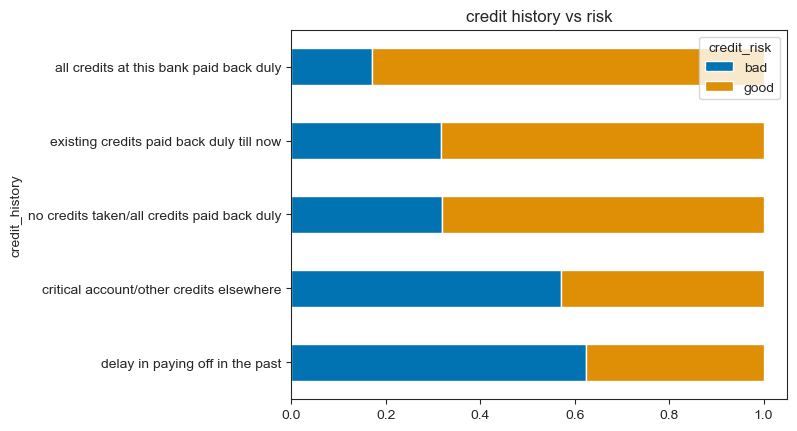

In [16]:
ct = pd.crosstab(df["credit_history"], df["credit_risk"], normalize = "index")
print(ct)
ct.plot(kind = "barh", stacked = True)
plt.title("credit history vs risk")


Compared to the baseline default rate of around 30%, borrowers with a history of delayed payments show substantially higher risk, while those with a clean repayment history exhibit significantly lower default rates.

credit_risk                                      bad      good
status                                                        
no checking account                         0.492701  0.507299
... < 0 DM                                  0.390335  0.609665
0<= ... < 200 DM                            0.222222  0.777778
... >= 200 DM / salary for at least 1 year  0.116751  0.883249


Text(0.5, 1.0, 'status vs risk')

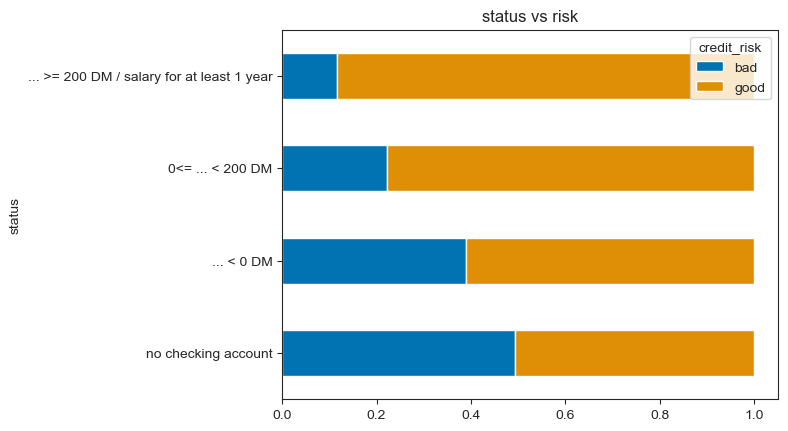

In [17]:
ct = pd.crosstab(df["status"], df["credit_risk"], normalize = "index")
print(ct)
ct.plot(kind = "barh", stacked = True)
plt.title("status vs risk")

Borrowers with no checking account or negative balance show increased risk, while those with a positive balance show a decrease of risk. Status seems to be a good indicator of risk.

credit_risk                      bad      good
savings                                       
unknown/no savings account  0.359867  0.640133
... <  100 DM               0.330097  0.669903
100 <= ... <  500 DM        0.174603  0.825397
500 <= ... < 1000 DM        0.125000  0.875000
... >= 1000 DM              0.174863  0.825137


Text(0.5, 1.0, 'savings vs risk')

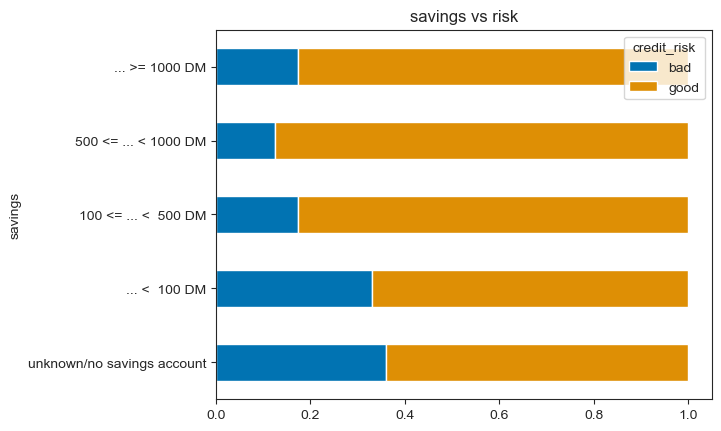

In [18]:
ct = pd.crosstab(df["savings"], df["credit_risk"], normalize = "index")
print(ct)
ct.plot(kind = "barh", stacked = True)
plt.title("savings vs risk")

Savings seem to have a significant impact on risk as different categories deviate greatly compared to the baseline for borrowers with more than 100 DM in their account.

credit_risk                                     bad      good
property                                                     
unknown / no property                      0.212766  0.787234
car or other                               0.306034  0.693966
building soc. savings agr./life insurance  0.307229  0.692771
real estate                                0.435065  0.564935


Text(0.5, 1.0, 'property vs risk')

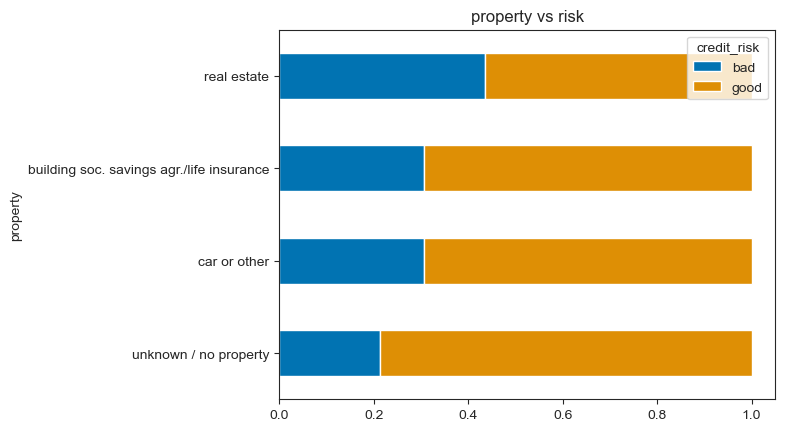

In [19]:
ct = pd.crosstab(df["property"], df["credit_risk"], normalize = "index")
print(ct)
ct.plot(kind = "barh", stacked = True)
plt.title("property vs risk")

Borrowers with unknown or no property show an increase in risk, while real estate owners show significantly less risk.

credit_risk            bad      good
installment_rate                    
>= 35             0.250000  0.750000
25 <= ... < 35    0.268398  0.731602
20 <= ... < 25    0.286624  0.713376
< 20              0.334034  0.665966


Text(0.5, 1.0, 'installment rate vs risk')

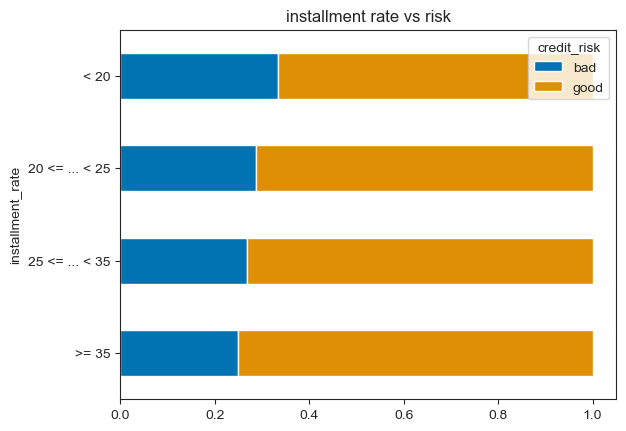

In [20]:
ct = pd.crosstab(df["installment_rate"], df["credit_risk"], normalize = "index")
print(ct)
ct.plot(kind = "barh", stacked = True)
plt.title("installment rate vs risk")

Credit amount in relation to disposable income does not seem to have a significant impact on credit risk.

credit_risk           bad      good
purpose_grouped                    
business         0.416667  0.583333
consumer         0.286058  0.713942
repairs          0.440000  0.560000
retraining       0.350515  0.649485
vacation         0.111111  0.888889


Text(0.5, 1.0, 'grouped purpose vs risk')

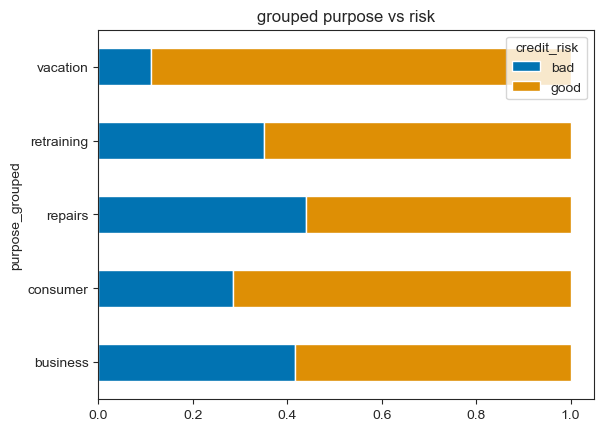

In [21]:
ct = pd.crosstab(df["purpose_grouped"], df["credit_risk"], normalize="index")
print(ct)
ct.plot(kind="barh", stacked=True)
plt.title("grouped purpose vs risk")

Credit purpose seems to have a significant impact on risk as different categories deviate greatly compared to the baseline.

credit_risk                                      bad      good
job                                                           
unemployed/unskilled - non-resident         0.318182  0.681818
unskilled - resident                        0.280000  0.720000
skilled employee/official                   0.295238  0.704762
manager/self-empl./highly qualif. employee  0.344595  0.655405


Text(0.5, 1.0, 'job vs risk')

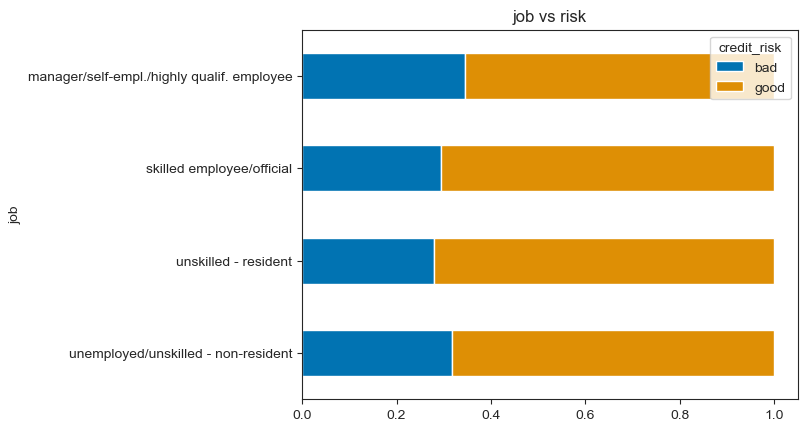

In [22]:
ct = pd.crosstab(df["job"], df["credit_risk"], normalize="index")
print(ct)
ct.plot(kind="barh", stacked=True)
plt.title("job vs risk")

Job Type does not seem to play a significant role in determining credit risk. Borrowers in the highest skill however show a slight improvement on risk.

credit_risk               bad      good
employment_duration                    
unemployed           0.370968  0.629032
< 1 yr               0.406977  0.593023
1 <= ... < 4 yrs     0.306785  0.693215
4 <= ... < 7 yrs     0.224138  0.775862
>= 7 yrs             0.252964  0.747036


Text(0.5, 1.0, 'employment duration vs risk')

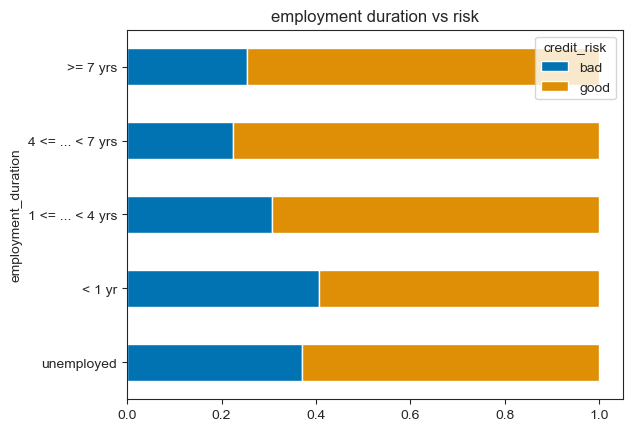

In [23]:
ct = pd.crosstab(df["employment_duration"], df["credit_risk"], normalize="index")
print(ct)
ct.plot(kind="barh", stacked=True)
plt.title("employment duration vs risk")

Higher employment durations seem to be associated with lower risk. However, this relationship does not seem to be linear.

## Statistical Summary

We complement the exploratory analysis with statistical tests and effect sizes, using Cohen"s d and Cramer"s V,
to assess the strength of relationships between features and credit risk.

In [24]:
#define analysing functions

# effect size
def cohens_d(x, y):
    x = x.dropna()
    y = y.dropna()
    return (x.mean() - y.mean()) / np.sqrt((x.std()**2 + y.std()**2) / 2)

def cramers_v(x, y):
    contingency = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency)[0]
    n = contingency.sum().sum()
    r, k = contingency.shape
    return np.sqrt(chi2 / (n * (min(r - 1, k - 1))))


# main function
def analyse_feature(df, feature):

    result = {}

    # numerical → t-test
    if pd.api.types.is_numeric_dtype(df[feature]):

        good = df[df["credit_risk"] == "good"][feature]
        bad = df[df["credit_risk"] == "bad"][feature]

        t_stat, p_value = ttest_ind(good, bad, equal_var=False)
        effect = cohens_d(good, bad)

        result["type"] = "numerical"
        result["test"] = "t-test"
        result["p_value"] = p_value
        result["effect_size"] = effect

        # interpretation effect size
        if abs(effect) < 0.2:
            interpretation = "weak effect"
        elif abs(effect) < 0.5:
            interpretation = "moderate effect"
        else:
            interpretation = "strong effect"

    # categorical -> chisquared test
    else:

        contingency = pd.crosstab(df[feature], df["credit_risk"])

        chi2, p_value, _, _ = chi2_contingency(contingency)
        effect = cramers_v(df[feature], df["credit_risk"])

        result["type"] = "categorical"
        result["test"] = "chi-square"
        result["p_value"] = p_value
        result["effect_size"] = effect

        # interpretation of effect size
        if effect < 0.1:
            interpretation = "weak association"
        elif effect < 0.3:
            interpretation = "moderate association"
        else:
            interpretation = "strong association"

    #statistical significance
    if p_value < 0.001:
        significance = "***"
    elif p_value < 0.01:
        significance = "**"
    elif p_value < 0.05:
        significance = "*"
    else:
        significance = ""

    result["significance"] = significance
    # general info
    result["n"] = len(df)
    result["interpretation"] = interpretation

    return pd.Series(result)

In [25]:
features = [col for col in df.columns if col not in ["credit_risk", "purpose"]]

results = pd.DataFrame([analyse_feature(df, col) for col in features], index=features)
results.sort_values("effect_size", ascending=False, inplace=True)
results_filtered = results[(results["effect_size"] > 0.1) & (results["p_value"]<0.05)]
results_filtered

,type,test,p_value,effect_size,significance,n,interpretation
status,categorical,chi-square,1.218902e-26,0.351740,***,1000,strong association
credit_history,categorical,chi-square,1.279187e-12,0.248378,***,1000,moderate association
age,numerical,t-test,3.778175e-03,0.200240,**,1000,moderate effect
savings,categorical,chi-square,2.761214e-07,0.189997,***,1000,moderate association
property,categorical,chi-square,2.858442e-05,0.154012,***,1000,moderate association
housing,categorical,chi-square,8.810311e-05,0.136653,***,1000,moderate association
employment_duration,categorical,chi-square,1.045452e-03,0.135530,**,1000,moderate association
other_installment_plans,categorical,chi-square,1.629318e-03,0.113310,**,1000,moderate association


### Statistical Significance and Effect Size

The statistical analysis shows that several features are significantly associated with credit risk, as indicated by low p-values. This confirms most of the assumptions made in the exploratory data analysis.

However, statistical significance alone is not sufficient for assessing practical relevance. Given the dataset size, even small differences can become statistically significant.

Effect sizes provide additional context by measuring the strength of these relationships. While some variables (e.g., credit history, checking account status) exhibit moderate to strong effects, many others show only weak effects despite being statistically significant.

This highlights that not all statistically significant variables are equally important from a risk management perspective.

## Summary of Key Drivers

The analysis shows that credit risk is primarily driven by:

- past repayment behavior (credit history)
- short-term financial liquidity (checking account status)
- assets (savings and property)

In contrast, variables such as credit amount, duration, job and installment rate show weaker individual effects.

Overall, the results suggest that credit risk cannot be explained by single variables alone, but rather emerges from the interaction of multiple factors. This aligns with real-world credit risk assessment, where decisions are based on a holistic view of the borrower rather than isolated indicators.

## Outlook and Next Steps

This analysis provides a structured understanding of the key drivers of credit risk based on exploratory data analysis and statistical testing.

As a next step, the insights gained here can be used to build predictive models for credit risk classification. Techniques such as logistic regression or tree-based models (e.g., decision trees, random forests, or gradient boosting) could help quantify the combined predictive power of the identified features.

In addition, feature engineering (e.g., interaction terms between credit amount, duration, and installment rate) and proper handling of categorical variables could further improve model performance.
